In [2]:
import glob,os
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [14]:
files = glob.glob(r".\\soma_sholl\*.csv")
dfall = pd.DataFrame()
for file in files:
    # print(file)
    df = pd.read_csv(file,index_col=0)
    dfall = pd.concat([dfall,df],axis=1)
dfall = dfall.fillna(0).T
dfall.to_csv(".\\all_neurons_sholl.csv")

In [5]:
dfall = pd.read_csv("all_neurons_sholl.csv",index_col=0)

In [9]:
dfc = pd.read_excel(r"D:\python\BLA_3_types\code\Fig1_B_SupFig1_B\bla_soma_type.xlsx",index_col=0)

In [13]:
dfc["type"] = dfc["type"].astype("str")

In [14]:
dfc["cluster"] = dfc["geno"]+"_"+dfc["type"]

In [18]:
dfall = pd.concat([dfc["cluster"],dfall],axis=1)

In [21]:
dfall2 = dfall.loc[dfall.index.str.contains("Sst")]

In [23]:
dfall2["cluster"] = dfall2["cluster"].str.replace("Sst_1","Sst_long")
dfall2["cluster"] = dfall2["cluster"].str.replace("Sst_2","Sst_local")
dfall2["cluster"] = dfall2["cluster"].str.replace("Sst_3","Sst_local")


C:\Users\zljia\AppData\Local\Temp\ipykernel_9044\473157019.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfall2["cluster"] = dfall2["cluster"].str.replace("Sst_1","Sst_long")
C:\Users\zljia\AppData\Local\Temp\ipykernel_9044\473157019.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfall2["cluster"] = dfall2["cluster"].str.replace("Sst_2","Sst_local")
C:\Users\zljia\AppData\Local\Temp\ipykernel_9044\473157019.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Dat

In [25]:
dfall2.to_csv("Sst_neurons_sholl.csv")

In [26]:
dfall= pd.read_csv("Sst_neurons_sholl.csv")
dfall["0.0"] = 0


In [ ]:
dfall["0.0"] = 0


In [28]:
dfall

,Unnamed: 0,cluster,10.0,20.0,30.0,40.0,50.0,60.0,70.0,80.0,...,920.0,930.0,940.0,950.0,960.0,970.0,980.0,990.0,1000.0,0.0
0,221058_038_Sst,Sst_long,6.0,12.0,16.0,17.0,19.0,18.0,15.0,15.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,221058_107_Sst,Sst_local,3.0,4.0,8.0,8.0,9.0,10.0,12.0,14.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,221297_038_Sst,Sst_long,2.0,9.0,16.0,18.0,19.0,21.0,22.0,21.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,252460_132_Sst,Sst_local,7.0,6.0,6.0,6.0,6.0,7.0,8.0,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,221058_040_Sst,Sst_local,6.0,5.0,6.0,6.0,8.0,9.0,10.0,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
5,242655_057_Sst,Sst_local,5.0,5.0,5.0,6.0,7.0,7.0,9.0,9.0,...,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0
6,230058_076_Sst,Sst_long,7.0,8.0,10.0,12.0,14.0,15.0,15.0,15.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
7,230058_078_Sst,Sst_long,7.0,8.0,10.0,13.0,14.0,15.0,15.0,15.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
8,252459_079_Sst,Sst_local,7.0,8.0,10.0,12.0,12.0,11.0,11.0,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
9,230058_074_Sst,Sst_long,6.0,7.0,12.0,19.0,23.0,21.0,20.0,19.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


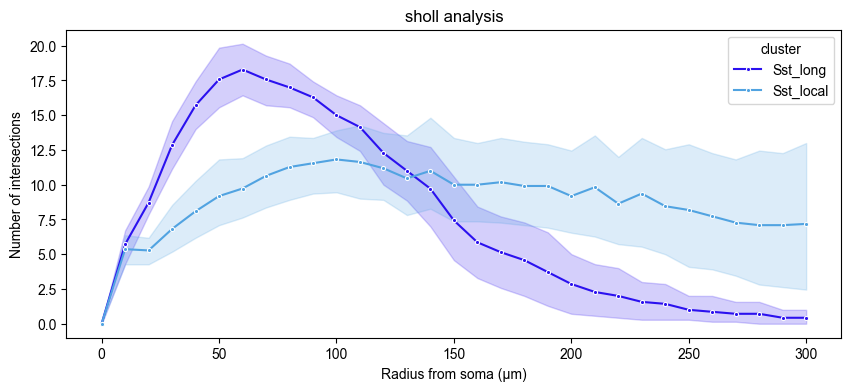

In [29]:
df_long = dfall.melt(
    id_vars=['Unnamed: 0', 'cluster'],  # 保留 sample 和 cluster
    var_name='x',                  # 原来的 10,20,30 → x
    value_name='value'             # 数值
)
df_long["x"] = pd.to_numeric(df_long["x"])
df_long2 = df_long.loc[df_long.x<=300]
import seaborn as sns
import matplotlib.pyplot as plt

import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
plt.rc("font",family="Arial")

plt.figure(figsize=(10,4))

dic_list = {"Sst_long":"#2B11EF","Sst_local":"#51a3e1"}

sns.lineplot(
    data=df_long2,
    x='x',          # 横轴
    y='value',      # 纵轴
    hue='cluster',  # 按 cluster 分组
    marker='.',
    palette = dic_list
)

plt.ylabel("Number of intersections")
plt.xlabel("Radius from soma (µm)")
plt.title('sholl analysis')
plt.savefig("sholl analysis_Sst.pdf",dpi=300)
plt.savefig("sholl analysis_Sst.jpg",dpi=300)